In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
train_df = pd.read_csv("../data/train_processed.csv")

print(train_df.shape)

train_df.head()

(103904, 29)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,4.0,3.0,4.0,4.0,5.0,5.0,25.0,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,1.0,5.0,3.0,1.5,4.0,1.0,1.0,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,4.0,3.0,4.0,4.0,4.0,5.0,0.0,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,2.0,5.0,3.0,1.5,4.0,2.0,11.0,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,0.0,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677


In [ ]:
cluster_features = [

    "Age",

    "Flight Distance",

    "Overall_Service_Score",

    "Comfort_Score",

    "Digital_Experience",

    "Travel_Experience",

    "Total_Delay",

    "Customer_Value"

]

X = train_df[cluster_features]

X.head()

,Age,Flight Distance,Overall_Service_Score,Comfort_Score,Digital_Experience,Travel_Experience,Total_Delay,Customer_Value
0,13.0,460.0,4.181818,4.333333,3.000000,3.838384,43.0,1923.636364
1,25.0,235.0,2.227273,2.333333,3.000000,2.520202,7.0,523.409091
2,26.0,1142.0,4.181818,4.333333,3.000000,3.838384,0.0,4775.636364
3,25.0,562.0,2.500000,3.000000,3.000000,2.833333,20.0,1405.000000
4,61.0,214.0,3.636364,4.000000,3.666667,3.767677,0.0,778.181818


In [ ]:
print(X.isnull().sum())

Age                      0
Flight Distance          0
Overall_Service_Score    0
Comfort_Score            0
Digital_Experience       0
Travel_Experience        0
Total_Delay              0
Customer_Value           0
dtype: int64


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
scaled_df = pd.DataFrame(

    X_scaled,

    columns=cluster_features

)

scaled_df.head()

,Age,Flight Distance,Overall_Service_Score,Comfort_Score,Digital_Experience,Travel_Experience,Total_Delay,Customer_Value
0,-1.745279,-0.734863,1.165011,1.018282,0.078029,0.835880,1.245652,-0.572943
1,-0.951360,-0.962567,-1.510487,-1.071789,0.078029,-0.891901,-0.373585,-0.945209
2,-0.885200,-0.044664,1.165011,1.018282,0.078029,0.835880,-0.688436,0.185295
3,-0.951360,-0.631637,-1.137162,-0.375099,0.078029,-0.481471,0.211140,-0.710828
4,1.430397,-0.983820,0.418360,0.669937,0.671314,0.743202,-0.688436,-0.877475


In [ ]:
inertia = []

for k in range(2,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

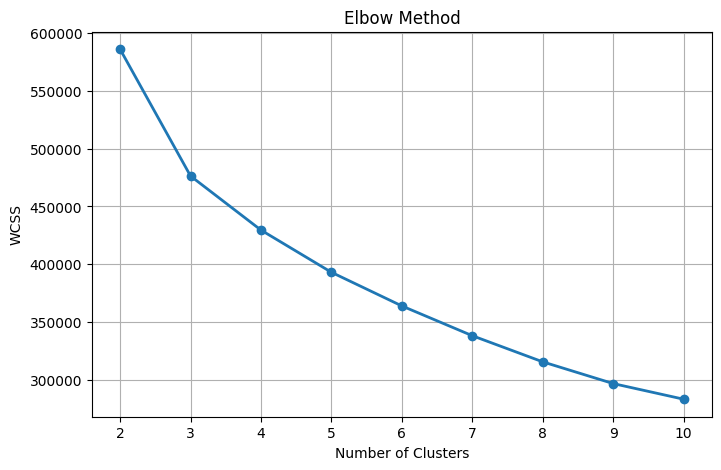

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    inertia,

    marker="o",

    linewidth=2

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import MiniBatchKMeans

scores = []

for k in range(2,11):

    model = MiniBatchKMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(X_scaled)

    scores.append(

        calinski_harabasz_score(

            X_scaled,

            labels

        )

    )

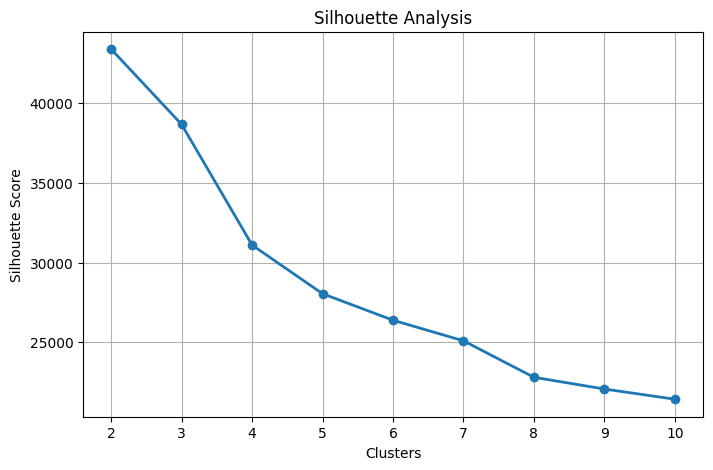

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    scores,

    marker="o",

    linewidth=2

)

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [ ]:
optimal_clusters = 4

In [ ]:
kmeans = KMeans(

    n_clusters=optimal_clusters,

    random_state=42,

    n_init=10

)

train_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
train_df["Cluster"].value_counts().sort_index()

Cluster
0    20353
1    14871
2    33193
3    35487
Name: count, dtype: int64

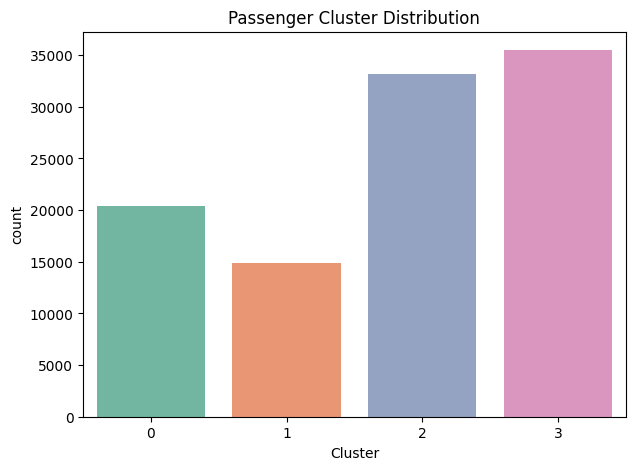

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=train_df,

    x="Cluster",

    palette="Set2"

)

plt.title("Passenger Cluster Distribution")

plt.show()

In [ ]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(

    pca_components,

    columns=["PC1","PC2"]

)

pca_df["Cluster"] = train_df["Cluster"]

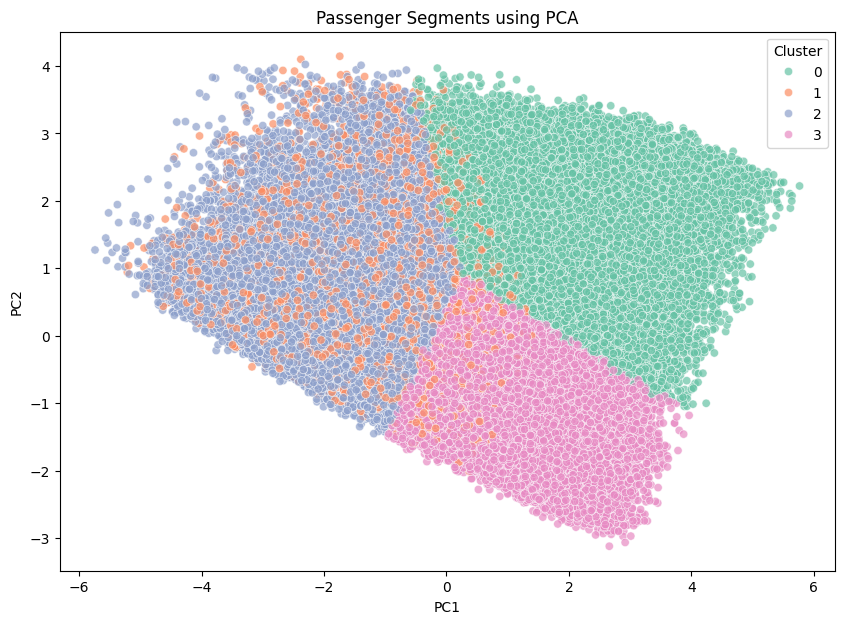

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    alpha=0.7

)

plt.title("Passenger Segments using PCA")

plt.show()

In [ ]:
cluster_profile = train_df.groupby("Cluster")[

    cluster_features + ["satisfaction"]

].mean().round(2)

cluster_profile

,Age,Flight Distance,Overall_Service_Score,Comfort_Score,Digital_Experience,Travel_Experience,Total_Delay,Customer_Value,satisfaction
Cluster,,,,,,,,,
0,43.89,2712.57,3.90,4.04,3.38,3.78,13.57,10510.22,0.85
1,37.56,895.57,2.95,2.94,2.53,2.81,55.66,2579.31,0.17
2,36.83,901.44,2.65,2.53,2.18,2.45,5.14,2333.42,0.15
3,39.95,698.73,3.80,3.92,3.49,3.74,8.89,2650.72,0.57


In [ ]:
cluster_profile["Passenger_Count"] = train_df.groupby(

    "Cluster"

).size()

cluster_profile

,Age,Flight Distance,Overall_Service_Score,Comfort_Score,Digital_Experience,Travel_Experience,Total_Delay,Customer_Value,satisfaction,Passenger_Count
Cluster,,,,,,,,,,
0,43.89,2712.57,3.90,4.04,3.38,3.78,13.57,10510.22,0.85,20353
1,37.56,895.57,2.95,2.94,2.53,2.81,55.66,2579.31,0.17,14871
2,36.83,901.44,2.65,2.53,2.18,2.45,5.14,2333.42,0.15,33193
3,39.95,698.73,3.80,3.92,3.49,3.74,8.89,2650.72,0.57,35487


In [ ]:
cluster_names = {

    0: "Premium Loyal Travelers",

    1: "Comfort-Focused Travelers",

    2: "Budget Frequent Travelers",

    3: "At-Risk Passengers"

}

train_df["Passenger_Segment"] = train_df["Cluster"].map(cluster_names)

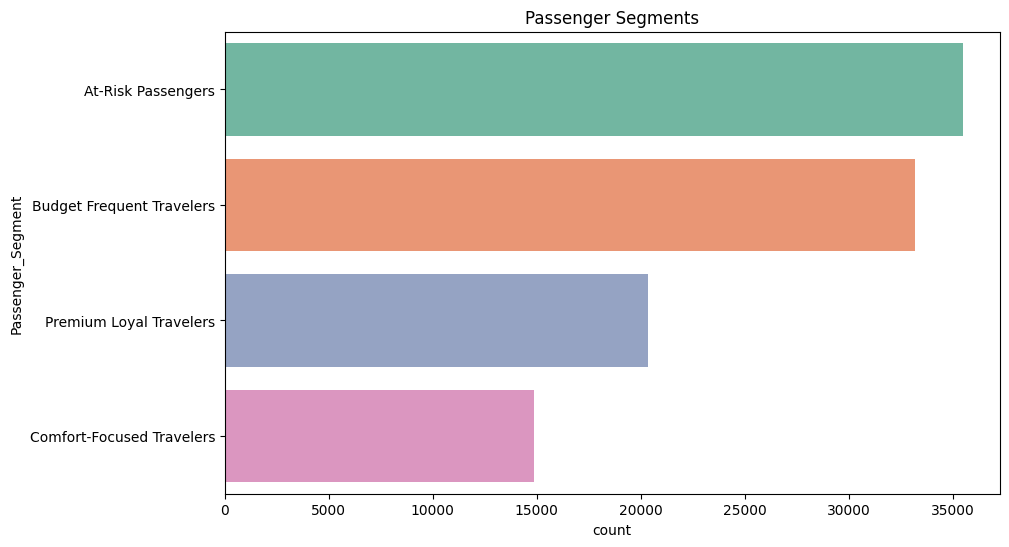

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=train_df,

    y="Passenger_Segment",

    order=train_df["Passenger_Segment"].value_counts().index,

    palette="Set2"

)

plt.title("Passenger Segments")

plt.show()

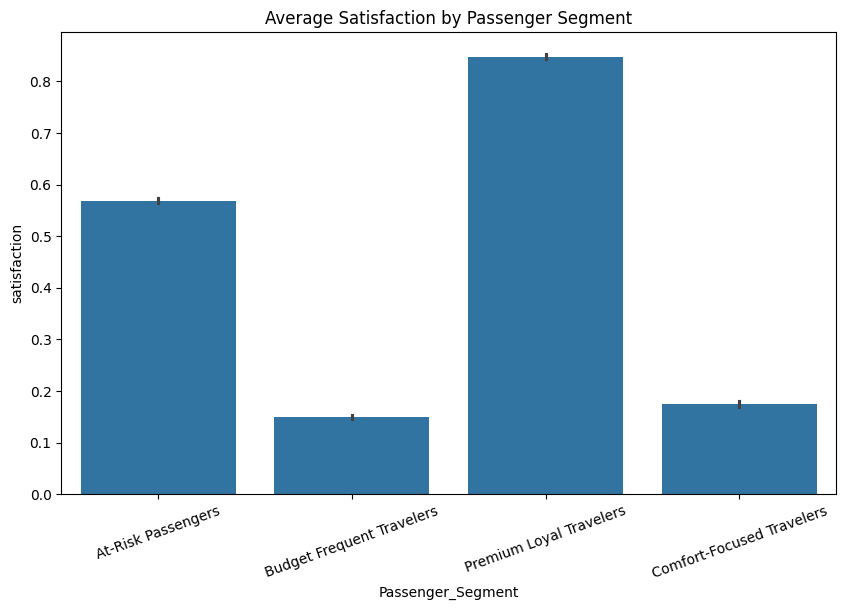

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=train_df,

    x="Passenger_Segment",

    y="satisfaction",

    estimator=np.mean

)

plt.xticks(rotation=20)

plt.title("Average Satisfaction by Passenger Segment")

plt.show()

In [ ]:
train_df.to_csv(

    "../data/train_clustered.csv",

    index=False

)

cluster_profile.to_csv(

    "../reports/cluster_profile.csv"
)

print("Clustering results saved successfully.")

Clustering results saved successfully.


In [ ]:
# View comparison table
comparison = pd.DataFrame({
    "Clusters": range(2, 11),
    "Inertia": inertia,
    "Silhouette Score": scores
})

comparison

,Clusters,Inertia,Silhouette Score
0,2,586178.158141,43397.536228
1,3,476342.578282,38672.687033
2,4,429480.932725,31101.046620
3,5,392914.600911,28046.166470
4,6,363757.979401,26383.067086
5,7,337973.944541,25089.316923
6,8,315322.525662,22800.375744
7,9,296505.875908,22064.059162
8,10,282967.618061,21423.472902


In [ ]:
kmeans.fit(X)

joblib.dump(kmeans, "models/kmeans.pkl")